[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 8s 107ms/step - loss: 0.0056 - val_loss: 0.0014
Epoch 2/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 0.0013 - val_loss: 0.0018
Epoch 3/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 7.6494e-04 - val_loss: 0.0015
Epoch 4/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - loss: 8.5792e-04 - val_loss: 0.0035
Epoch 5/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - loss: 8.7919e-04 - val_loss: 0.0026
Epoch 6/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - loss: 8.8363e-04 - val_loss: 0.0021
Epoch 7/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 7.4328e-04 - val_loss: 0.0024
Epoch 8/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 6.3884e-04 - val_loss: 0.0010
Epoch 9/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 7.3882e-04 - val_loss: 0.0011
Epoch 10/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 6.8427e-04 - val_loss: 0.0011
Epoch 11/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - loss: 6.4252e-04 - val_loss: 0.0010
Epoch 12/20
41/41 ━━━━━━━━

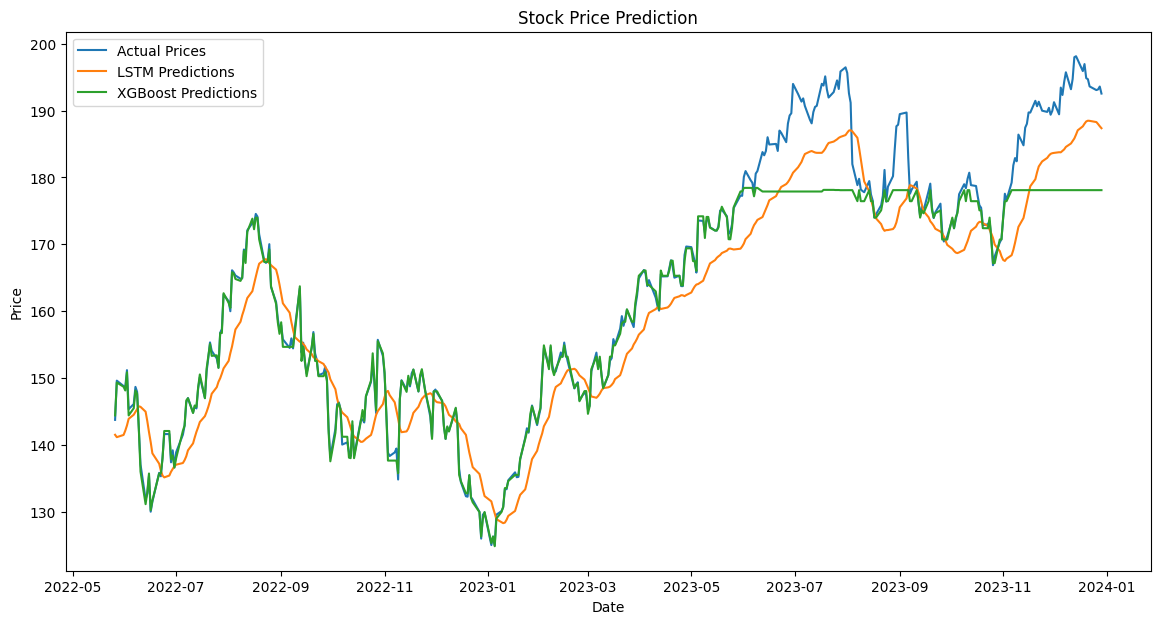

In [ ]:
# Stock Prediction Analysis in Jupyter Notebook

# 1. Import necessary libraries
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
import tensorflow as tf
from tensorflow.keras.models import Sequential  # 123
from tensorflow.keras.layers import LSTM, Dense, Dropout  # 123

# 2. Fetch historical stock data using yfinance
def fetch_stock_data(ticker, start_date, end_date):
    stock_data = yf.download(ticker, start=start_date, end=end_date)
    return stock_data

# Example: Fetch Apple stock data from 2015 to 2024
stock_data = fetch_stock_data('AAPL', '2015-01-01', '2024-01-01')

# 3. Data Preprocessing
# Drop rows with missing values
stock_data = stock_data.dropna()

# Feature engineering: Add Moving Average (50 and 200 days)
stock_data['MA50'] = stock_data['Close'].rolling(window=50).mean()
stock_data['MA200'] = stock_data['Close'].rolling(window=200).mean()

# Remove any rows with NaN values after adding moving averages
stock_data = stock_data.dropna()

# Use 'Close' prices as the target variable
close_prices = stock_data['Close'].values

# Scaling the data for LSTM (between 0 and 1)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(close_prices.reshape(-1, 1))

# 4. Create sequences for LSTM model (look back window of 60 days)
def create_sequences(data, look_back=60):
    sequences = []
    labels = []
    for i in range(len(data) - look_back):
        sequences.append(data[i:i+look_back])
        labels.append(data[i+look_back])
    return np.array(sequences), np.array(labels)

look_back = 60
X, y = create_sequences(scaled_data, look_back)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# 5. LSTM Model
def build_lstm_model(input_shape):
    model = Sequential()  # 123
    model.add(LSTM(units=50, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(LSTM(units=50, return_sequences=False))
    model.add(Dropout(0.2))
    model.add(Dense(units=1))  # Output layer for regression
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

lstm_model = build_lstm_model((X_train.shape[1], X_train.shape[2]))

# Train the LSTM model
history = lstm_model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# 6. Predict using LSTM
lstm_predictions = lstm_model.predict(X_test)

# Rescale the predictions back to original scale
lstm_predictions_rescaled = scaler.inverse_transform(lstm_predictions)
y_test_rescaled = scaler.inverse_transform(y_test.reshape(-1, 1))

# 7. XGBoost Model
# Prepare features for XGBoost (use more features like MA50, MA200)
features = stock_data[['Close', 'MA50', 'MA200']].iloc[look_back:].values
target = close_prices[look_back:]

# Split data into train and test sets for XGBoost
X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(features, target, test_size=0.2, shuffle=False)

# Build and train XGBoost model
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1)
xgb_model.fit(X_train_xgb, y_train_xgb)

# Predict using XGBoost
xgb_predictions = xgb_model.predict(X_test_xgb)

# 8. Evaluation
# LSTM RMSE
lstm_rmse = np.sqrt(mean_squared_error(y_test_rescaled, lstm_predictions_rescaled))
print(f"LSTM RMSE: {lstm_rmse}")

# XGBoost RMSE
xgb_rmse = np.sqrt(mean_squared_error(y_test_xgb, xgb_predictions))
print(f"XGBoost RMSE: {xgb_rmse}")

# 9. Visualization
plt.figure(figsize=(14, 7))
plt.plot(stock_data.index[-len(y_test):], y_test_rescaled, label="Actual Prices")
plt.plot(stock_data.index[-len(lstm_predictions_rescaled):], lstm_predictions_rescaled, label="LSTM Predictions")
plt.plot(stock_data.index[-len(xgb_predictions):], xgb_predictions, label="XGBoost Predictions")
plt.title('Stock Price Prediction')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()


In [ ]:
print(stock_data.head())
print(stock_data.index)
print(stock_data.iloc[0])


Price                      Adj Close      Close     High        Low  \
Ticker                          AAPL       AAPL     AAPL       AAPL   
Date                                                                  
2015-10-16 00:00:00+00:00  25.042110  27.760000  28.0000  27.632500   
2015-10-19 00:00:00+00:00  25.197721  27.932501  27.9375  27.527500   
2015-10-20 00:00:00+00:00  25.657785  28.442499  28.5425  27.705000   
2015-10-21 00:00:00+00:00  25.655535  28.440001  28.8950  28.424999   
2015-10-22 00:00:00+00:00  26.047941  28.875000  28.8750  28.525000   

Price                           Open     Volume      MA50      MA200  
Ticker                          AAPL       AAPL                       
Date                                                                  
2015-10-16 00:00:00+00:00  27.945000  156930400  28.08690  30.332337  
2015-10-19 00:00:00+00:00  27.700001  119036800  28.06795  30.335337  
2015-10-20 00:00:00+00:00  27.834999  195871200  28.03820  30.344737  
2015-

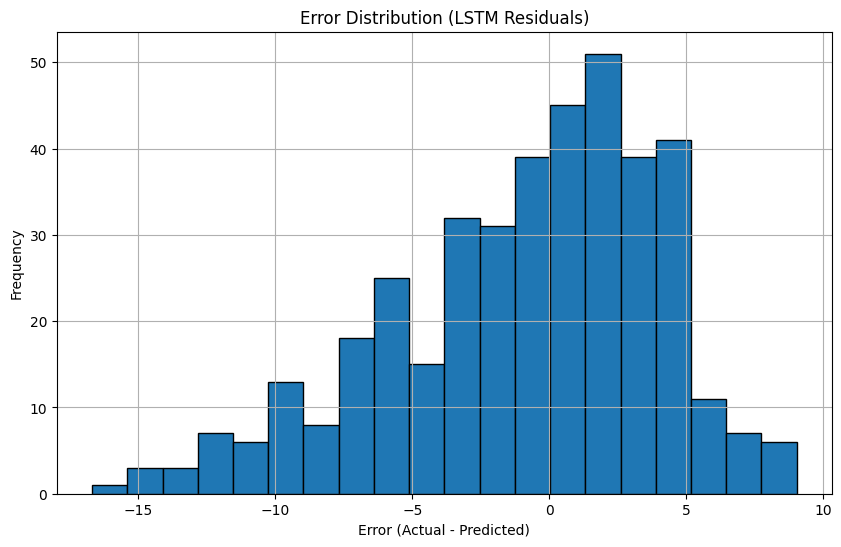

LSTM Mean Absolute Error (MAE): 3.869241481410001


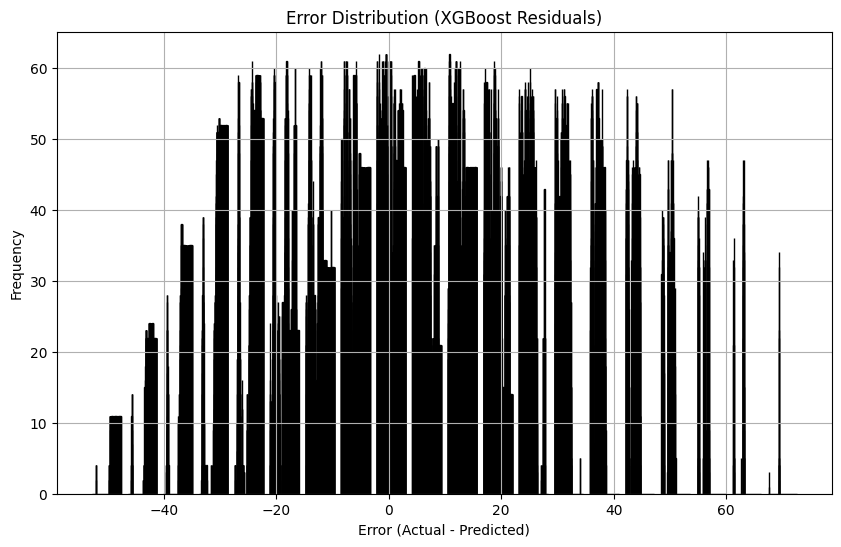

XGBoost Mean Absolute Error (MAE): 20.286998821585474


In [ ]:
# 10. Error Distribution Analysis (Residuals)
# Calculate residuals (errors) for LSTM model
lstm_residuals = y_test_rescaled - lstm_predictions_rescaled

# Plot the residuals to understand error distribution
plt.figure(figsize=(10, 6))
plt.hist(lstm_residuals, bins=20, edgecolor='black')
plt.title("Error Distribution (LSTM Residuals)")
plt.xlabel("Error (Actual - Predicted)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

# 11. Mean Absolute Error (MAE) for LSTM
lstm_mae = np.mean(np.abs(lstm_residuals))
print(f"LSTM Mean Absolute Error (MAE): {lstm_mae}")

# 12. Error Distribution Analysis for XGBoost Model
# Calculate residuals for XGBoost model
xgb_residuals = y_test_xgb - xgb_predictions

# Plot the residuals to understand error distribution
plt.figure(figsize=(10, 6))
plt.hist(xgb_residuals, bins=20, edgecolor='black')
plt.title("Error Distribution (XGBoost Residuals)")
plt.xlabel("Error (Actual - Predicted)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

# 13. Mean Absolute Error (MAE) for XGBoost
xgb_mae = np.mean(np.abs(xgb_residuals))
print(f"XGBoost Mean Absolute Error (MAE): {xgb_mae}")
